## This notebook serves to help use the GroundTruth class
### There is example code to quickly start using it 

In [ ]:
import numpy as np
from DataGenerator import GroundTruth

Example 1: Basic Usage (Default Saddle Field)
Here, we create a standard 40x40 simulation. We don't pass a gt_generator_func, so it uses the _default_saddle_field.

--- Creating default simulation (40x40 grid) ---
Plotting Ground Truth...


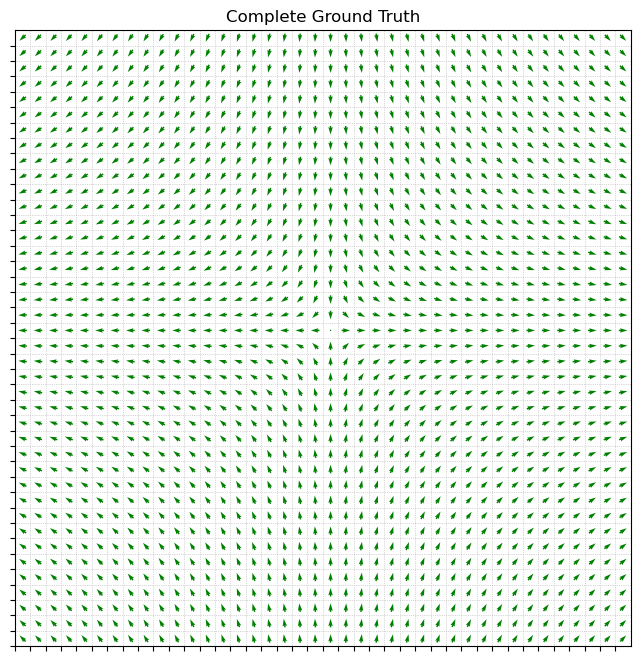

Plotting Microscopy (Sampled) Data...


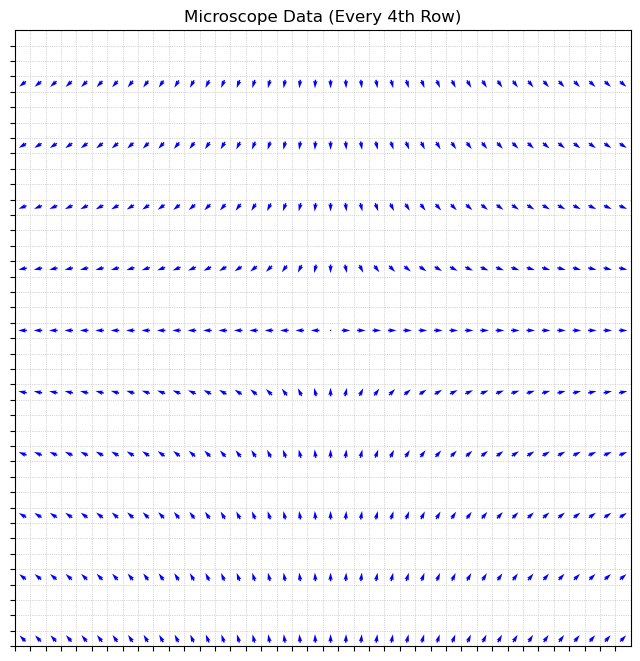

Plotting DWI (Patched) Overlay...


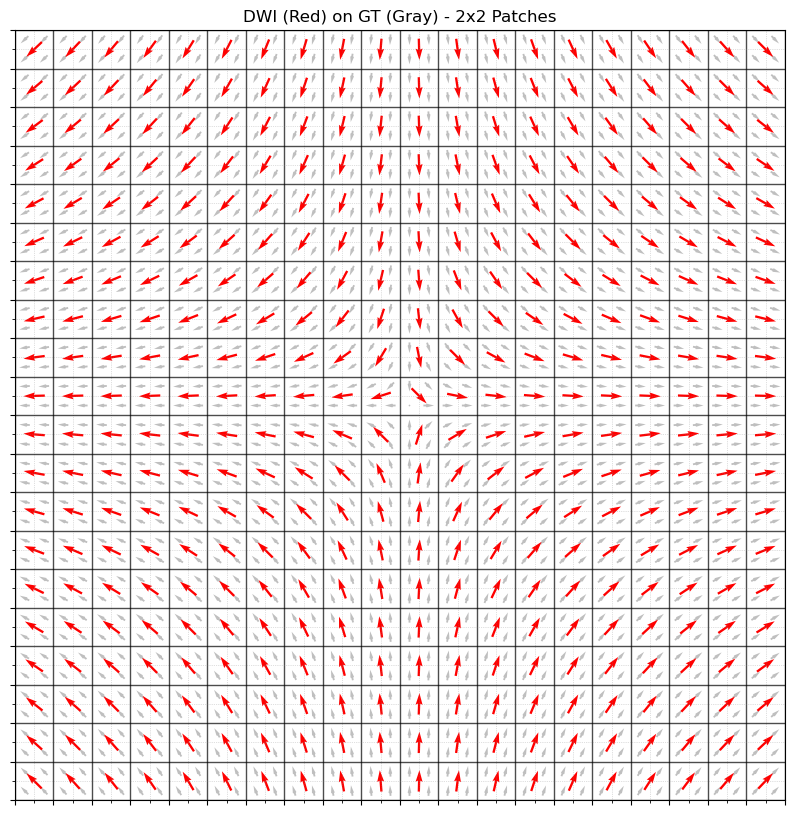

In [2]:
print("--- Creating default simulation (40x40 grid) ---")
sim_default = GroundTruth(size=40, microscopy_sample_rate=4, dwi_patch_size=2)

print("Plotting Ground Truth...")
sim_default.plot_ground_truth()

print("Plotting Microscopy (Sampled) Data...")
sim_default.plot_microscopy()

print("Plotting DWI (Patched) Overlay...")
sim_default.plot_dwi_overlay()

Example 2: Using a Custom Ground Truth (Vortex Field)
Now, we'll pass the create_vortex_field function to the constructor. All plots and derived data (dwi_grid) will now be based on this new field.

In [3]:
def create_vortex_field(X, Y, size):
    """
    Generates a 'vortex' vector field.
    
    Args:
        X (np.array): Meshgrid X-coordinates.
        Y (np.array): Meshgrid Y-coordinates.
        size (int): The width/height of the grid.
        
    Returns:
        np.array: A (size, size, 2) array of normalized vectors.
    """
    center_x, center_y = size / 2, size / 2
    epsilon = 1e-10  # For safe normalization

    # Create the vortex field
    u_vortex = -(Y - center_y)
    v_vortex = (X - center_x)
    
    # Normalize the vectors
    magnitude = np.sqrt(u_vortex**2 + v_vortex**2) + epsilon
    u_normalized = u_vortex / magnitude
    v_normalized = v_vortex / magnitude
    
    return np.stack((u_normalized, v_normalized), axis=-1)

--- Creating simulation with custom vortex field ---
Plotting Vortex Ground Truth...


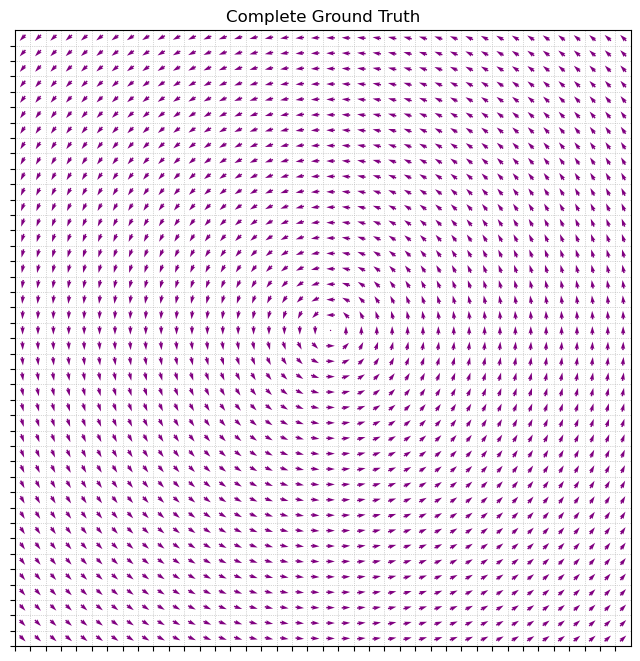

Plotting DWI overlay for Vortex...


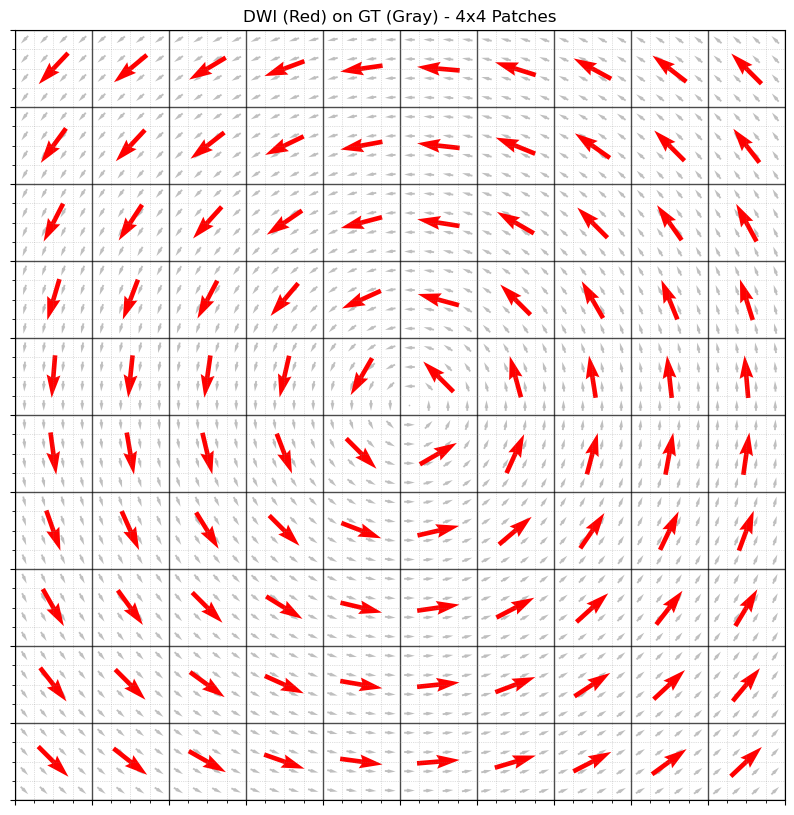

In [4]:
print("--- Creating simulation with custom vortex field ---")
sim_vortex = GroundTruth(size=40, dwi_patch_size=4, gt_generator_func=create_vortex_field)

print("Plotting Vortex Ground Truth...")
sim_vortex.plot_ground_truth(color='purple')

print("Plotting DWI overlay for Vortex...")
sim_vortex.plot_dwi_overlay()

Example 3: Modifying Simulation Parameters
Let's see the effect of changing the dwi_patch_size to be much larger. We'll re-use the vortex field.

--- Creating simulation with large DWI patches (8x8) ---
Plotting DWI overlay for 8x8 patches...


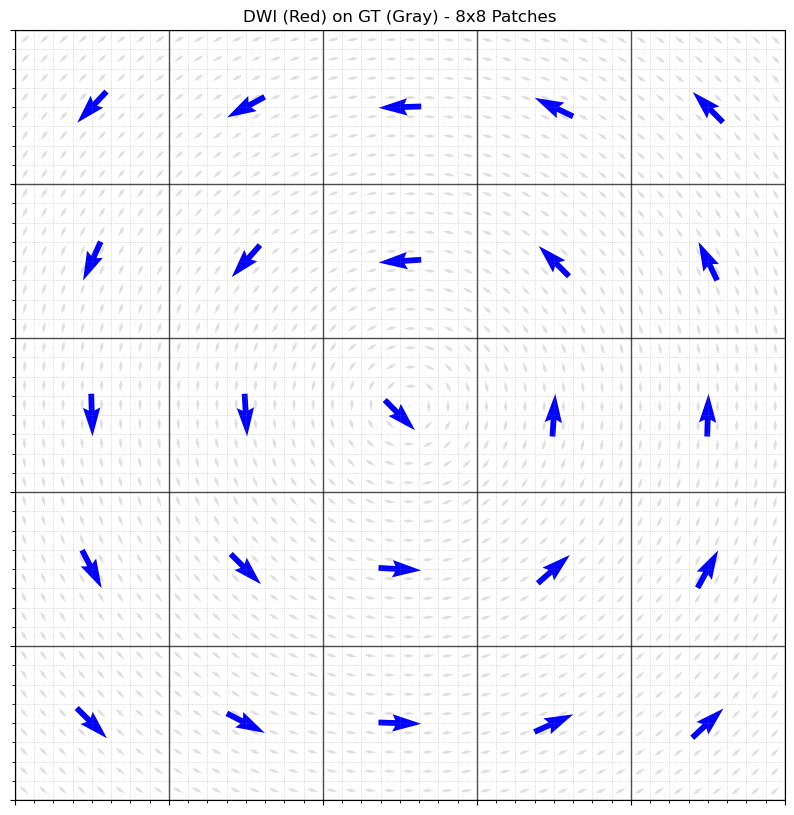

In [5]:
print("--- Creating simulation with large DWI patches (8x8) ---")
sim_large_patch = GroundTruth(size=40, dwi_patch_size=8, gt_generator_func=create_vortex_field)

print("Plotting DWI overlay for 8x8 patches...")
sim_large_patch.plot_dwi_overlay(gt_color='silver', dwi_color='blue')

Example 4: Accessing the NumPy Data for Tractography
This is the key for your work. You can access the generated data directly from the class attributes. These NumPy arrays are the inputs for your algorithms.

In [6]:
print("--- Accessing data from the 'sim_vortex' instance --- (from Example 2)")

# Get the data arrays
gt_data = sim_vortex.gt_grid
microscopy_data = sim_vortex.microscopy_grid
dwi_data = sim_vortex.dwi_grid

# --- Ground Truth Data ---
print(f"\nGround Truth Data Shape: {gt_data.shape}")
print(f"Example vector at (10, 10): {gt_data[10, 10]}")

# --- Microscopy Data ---
print(f"\nMicroscopy Data Shape: {microscopy_data.shape}")
print(f"Example vector at (4, 15) (sampled row): {microscopy_data[4, 15]}")
print(f"Example vector at (5, 15) (empty row): {microscopy_data[5, 15]}")

# --- DWI Data ---
# Note: sim_vortex had size=40 and dwi_patch_size=4, so dwi_data is 10x10
print(f"\nDWI Data Shape: {dwi_data.shape}")
print(f"Example vector at (5, 5) in coarse grid: {dwi_data[5, 5]}")

print("\nThese arrays are now ready to be used in your algorithms!")

--- Accessing data from the 'sim_vortex' instance --- (from Example 2)

Ground Truth Data Shape: (40, 40, 2)
Example vector at (10, 10): [ 0.70710678 -0.70710678]

Microscopy Data Shape: (40, 40, 2)
Example vector at (4, 15) (sampled row): [ 0.95447998 -0.29827499]
Example vector at (5, 15) (empty row): [nan nan]

DWI Data Shape: (10, 10, 2)
Example vector at (5, 5) in coarse grid: [-0.70710678  0.70710678]

These arrays are now ready to be used in your algorithms!
